In [1]:
import os
os.chdir('/Users/zhanwenxin/Documents/GitHub/canari')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

In [2]:
samples = pd.read_csv('data/hsl_tsad_training_samples/itv_learn_samples_toy_lstm_multi_anm_V2.csv')
samples['LTd_history'] = samples['LTd_history'].apply(lambda x: list(map(float, x[1:-1].split(','))))
# Convert samples['anm_develop_time'] to float
samples['anm_develop_time'] = samples['anm_develop_time'].apply(lambda x: float(x))
samples['anm_type'] = samples['anm_type'].map({'LL': 0.0, 'LT': 1.0}).astype(float)

# # Shuffle samples
samples = samples.sample(frac=1).reset_index(drop=True)

# Target list
target_list = ['itv_LT', 'itv_LL', 'anm_develop_time', 'anm_type']

samples_input = np.array(samples['LTd_history'].values.tolist(), dtype=np.float32)
samples_target = np.array(samples[target_list].values, dtype=np.float32)
samples_p_anm = np.array(samples['p_anm'].values.tolist(), dtype=np.float32)

# Find where anm_develop_time is 0
zero_indices = np.where(samples_target[:, 2] == 0)[0]
# Remove those samples
samples_input = np.delete(samples_input, zero_indices, axis=0)
samples_target = np.delete(samples_target, zero_indices, axis=0)
samples_p_anm = np.delete(samples_p_anm, zero_indices, axis=0)

panm_b5_indices = np.where(samples_p_anm > 0.5)[0]
samples_p_anm = np.delete(samples_p_anm, panm_b5_indices, axis=0)
samples_input = np.delete(samples_input, panm_b5_indices, axis=0)
samples_target = np.delete(samples_target, panm_b5_indices, axis=0)

# anm_type_indices = np.where(samples_target[:, -1] == 0)[0]
# samples_input = samples_input[anm_type_indices]
# samples_target = samples_target[anm_type_indices]
# samples_p_anm = samples_p_anm[anm_type_indices]

print(samples_input.shape)

num_plot_samples = 5000
samples_input = samples_input[0:num_plot_samples]
samples_target = samples_target[0:num_plot_samples]
samples_p_anm = samples_p_anm[0:num_plot_samples]

# Convert samples_target[:, 2] to grayscale that will be used later in the plot
grayscale_anm_dev_time = (samples_target[:, 2] - samples_target[:, 2].min()) / (samples_target[:, 2].max() - samples_target[:, 2].min())
grayscale_anm_type = (samples_target[:, -1] - samples_target[:, -1].min()) / (samples_target[:, -1].max() - samples_target[:, -1].min())
grayscale_p_anm = (samples_p_anm - samples_p_anm.min()) / (samples_p_anm.max() - samples_p_anm.min())

(69603, 8)


In [3]:
samples_input = samples_input[:, ::-1]

In [4]:
# # Plot a 3d graph with grayscale_anm_dev_time as the third dimension, the first and second dimensions are samples_input
# fig = plt.figure(figsize=(12, 6))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# ax1 = fig.add_subplot(gs[0], projection='3d')
# for i in range(samples_input.shape[0]):
#     ax1.plot(np.arange(len(samples_input[i])), samples_input[i], grayscale_anm_dev_time[i], color='black', alpha=0.5)
# # ax1.set_xlabel('LTd_history[0]')
# # ax1.set_ylabel('LTd_history[1]')

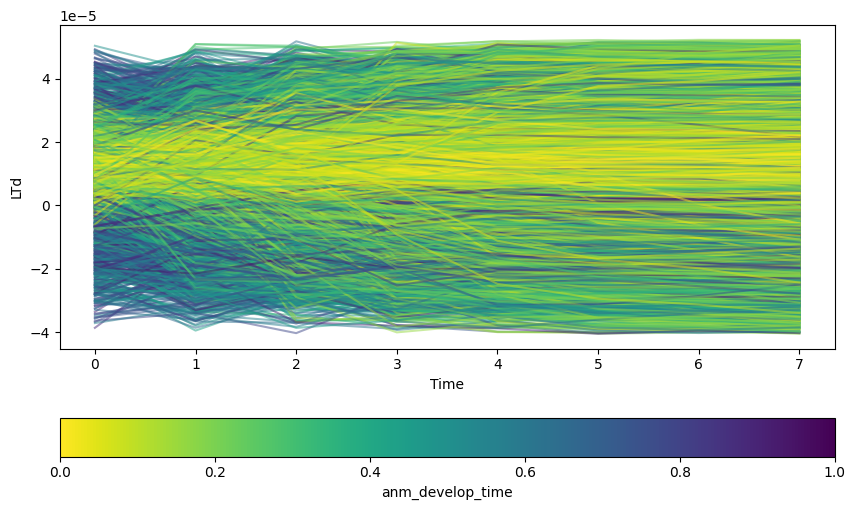

In [5]:
# Plot all samples input
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])
# ax.plot(samples_input.T, color='black', alpha=0.1)
# Plot samples_input with color based on grayscale_anm_dev_time
for i in range(samples_input.shape[0]):
    ax.plot(samples_input[i], color=plt.cm.viridis_r(grayscale_anm_dev_time[i]), alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('LTd')
# Plot the color map
fig.colorbar(plt.cm.ScalarMappable(cmap='viridis_r'), ax=ax, orientation='horizontal', label='anm_develop_time')

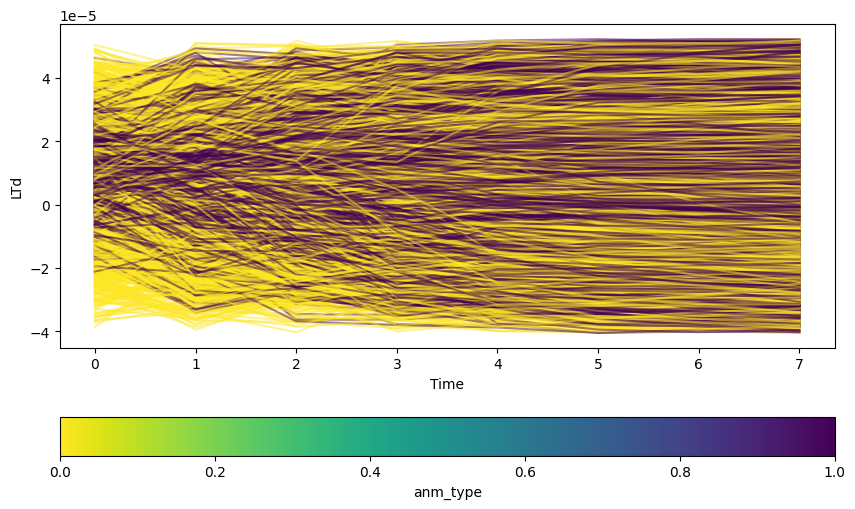

In [8]:
# Plot all samples input
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])
# ax.plot(samples_input.T, color='black', alpha=0.1)
# Plot samples_input with color based on grayscale_anm_dev_time
for i in range(samples_input.shape[0]):
    ax.plot(samples_input[i], color=plt.cm.viridis_r(grayscale_anm_type[i]), alpha=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('LTd')
# Plot the color map
# fig.colorbar(plt.cm.ScalarMappable(cmap='viridis_r'), ax=ax, orientation='horizontal', label='anm_develop_time')
fig.colorbar(plt.cm.ScalarMappable(cmap='viridis_r'), ax=ax, orientation='horizontal', label='anm_type')

In [7]:
# # Plot all samples input
# fig = plt.figure(figsize=(10, 6))
# gs = gridspec.GridSpec(1, 1)
# ax = fig.add_subplot(gs[0])
# # ax.plot(samples_input.T, color='black', alpha=0.1)
# # Plot samples_input with color based on grayscale_p_anm
# for i in range(samples_input.shape[0]):
#     ax.plot(samples_input[i], color=plt.cm.viridis_r(grayscale_p_anm[i]), alpha=0.5)
# ax.set_xlabel('Time')
# ax.set_ylabel('LTd')
# # Plot the color map
# fig.colorbar(plt.cm.ScalarMappable(cmap='viridis_r'), ax=ax, orientation='horizontal', label='anm_develop_time')
